# IMT 573 - Final Examination


Points: 100

Name: Richie Dait

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Richie Dait 

11/23/2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [674]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import io

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [675]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [676]:
affairs.head() #Display first 5 rows of dataset.

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [677]:
affairs.describe() #Display statistics of numerical columns.

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
count,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000
mean,4.109645,29.082862,9.009425,1.396874,2.426170,14.209865,3.424128,3.850141,0.705374
std,0.961430,6.847882,7.280120,1.433471,0.878369,2.178003,0.942399,1.346435,2.203374
min,1.000000,17.500000,0.500000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000
25%,4.000000,22.000000,2.500000,0.000000,2.000000,12.000000,3.000000,3.000000,0.000000
50%,4.000000,27.000000,6.000000,1.000000,2.000000,14.000000,3.000000,4.000000,0.000000
75%,5.000000,32.000000,16.500000,2.000000,3.000000,16.000000,4.000000,5.000000,0.484848
max,5.000000,42.000000,23.000000,5.500000,4.000000,20.000000,6.000000,6.000000,57.599991


In [678]:
affairs[['age', 'children']].agg(['mean']) #Display average/mean of age of respondents and count of children.

,age,children
mean,29.082862,1.396874


In [679]:
affairs.groupby('affairs').agg(['mean', 'median', 'count', 'min', 'max']).head() #Groupby the affairs column, displaying the mean, median, count, min and max of the other columns.

rate_marriage                               age                     \
                  mean median count  min  max       mean median count   min   
affairs                                                                       
0.000000      4.329701    5.0  4313  1.0  5.0  28.390679   27.0  4313  17.5   
0.043478      3.681818    3.5    22  2.0  5.0  41.090909   42.0    22  37.0   
0.060606      4.318182    5.0    22  1.0  5.0  33.363636   32.0    22  27.0   
0.076923      3.160000    4.0    25  1.0  5.0  31.800000   32.0    25  27.0   
0.111111      3.862069    4.0    29  2.0  5.0  29.413793   27.0    29  27.0   

                ... occupation                        occupation_husb         \
           max  ...       mean median count  min  max            mean median   
affairs         ...                                                            
0.000000  42.0  ...   3.405286    3.0  4313  1.0  6.0        3.833758    4.0   
0.043478  42.0  ...   3.681818    4.0    22  2.0  5.0        4.363636    4.5   
0.060606  42.0  ...   3.363636    3.0    22  2.0  5.0        4.227273    4.0   
0.076923  42.0  ...   3.480000    3.0    25  2.0  6.0        3.640000    4.0   
0.111111  32.0  ...   3.620690    4.0    29  2.0  6.0        4.137931    4.0   

                          
         count  min  max  
affairs                   
0.000000  4313  1.0  6.0  
0.043478    22  2.0  6.0  
0.060606    22  3.0  6.0  
0.076923    25  1.0  6.0  
0.111111    29  2.0  6.0  

[5 rows x 40 columns]

In [680]:
affairs.groupby('affairs').agg(['mean', 'median', 'count', 'min', 'max']).tail() #Groupby the affairs column, displaying the mean, median, count, min and max of the other columns.

rate_marriage                               age                     \
                   mean median count  min  max       mean median count   min   
affairs                                                                        
25.599991           3.0    3.0     2  3.0  3.0  22.000000   22.0     2  22.0   
26.879990           3.0    2.0     3  2.0  5.0  23.666667   22.0     3  22.0   
38.399994           3.0    3.0     1  3.0  3.0  27.000000   27.0     1  27.0   
39.199982           3.0    3.0     1  3.0  3.0  22.000000   22.0     1  22.0   
57.599991           5.0    5.0     1  5.0  5.0  22.000000   22.0     1  22.0   

                 ... occupation                        occupation_husb         \
            max  ...       mean median count  min  max            mean median   
affairs          ...                                                            
25.599991  22.0  ...        2.5    2.5     2  2.0  3.0             2.5    2.5   
26.879990  27.0  ...        4.0    4.0     3  2.0  6.0             3.0    3.0   
38.399994  27.0  ...        4.0    4.0     1  4.0  4.0             6.0    6.0   
39.199982  22.0  ...        3.0    3.0     1  3.0  3.0             2.0    2.0   
57.599991  22.0  ...        3.0    3.0     1  3.0  3.0             5.0    5.0   

                           
          count  min  max  
affairs                    
25.599991     2  2.0  3.0  
26.879990     3  2.0  4.0  
38.399994     1  6.0  6.0  
39.199982     1  2.0  2.0  
57.599991     1  5.0  5.0  

[5 rows x 40 columns]

##### The average age of respondents is a little over 29 years of age and average of number of children is approximately 1.4.

##### Describing the participants even more, grouping by the affairs column, the average age of those who did not engage in extramarital affair was 28.390679, while the average age of those who spent most time in extramarital affairs was 22. The maximum age of those who did not engage in extramarital affair was 42, while the maximum age of those who spent most time in extramarital affairs was 22.

##### Ethical concerns with the dataset include potential misuse and drawing conclusions about a certain demographic based on inaccurate data. Privacy concerns include the (mis)management and security of sensitive information. Hopefully, informed consent was given, detailing what data was collected, which data was excluded (e.g., name, address) and what will be shared (and with who).

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [681]:
affairs['affairs'].value_counts() #Display value counts to get an idea of the binary outcome.

affairs
0.000000     4313
1.400000      118
0.583333       86
0.400000       72
1.333333       72
             ... 
3.878787        1
7.111111        1
39.199982       1
4.923077        1
57.599991       1
Name: count, Length: 77, dtype: int64

In [682]:
affairs['Had_Affair'] = (affairs['affairs'] > 0).astype(int) #Create new variable with any value above 0 is assigned 1 for had affair, 0 for did not have an affair.
affairs['Had_Affair'].value_counts() #Value counts of participants who had an affair and did not have an affair.

Had_Affair
0    4313
1    2053
Name: count, dtype: int64

In [683]:
affairs.head() #Display first 5 rows with new variable.

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,Had_Affair
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1


##### The advantages to this approach compared to modeling is you can clearly see the difference in numbers between those who engaged in extramarital affairs and those who did not (2053 vs 4313).

##### One disadvantage is it does not provide much detail other than the number of participants who had affairs vs those who did not. Another disadvantage is you are not able to see which variables have influence, positive or negative. Lastly, you will interpreting the data through one output vs modeling where the result is easy to interpret and understand. Predictors can be used to explain the probability of an event.

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [684]:
affairs['constant'] = 1 #Add constant.
affairs = affairs.drop('affairs', axis = 1)

In [685]:
lr_model = sm.Logit(affairs['Had_Affair'], affairs.drop('Had_Affair', axis = 1)) #Set up logistic regression model.
model = lr_model.fit() #Fit model
model.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1327
Time:                        09:31:48   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
rate_marriage      -0.7161      0.031    -22.784      0.000      -0.778      -0.655
age                -0.0605      0.010     -5.885      0.000      -0.081      -0.040
yrs_married         0.1100      0.011     10.054      0.000       0.089       0.131
children           -0.0042      0.032     -0.134      0.893      -0.066       0.058
religious          -0.3752      0.035    -10.792      0.000      -0.443      -0.307
educ               -0.0392      0.015     -2.533      0.011      -0.070      -0.009
occupation          0.1602      0.034      4.717      0.000       0.094       0.227
occupation_husb     0.0124      0.023      0.541      0.589      -0.033       0.057
constant            3.7257      0.299     12.470      0.000       3.140       4.311
===================================================================================
"""

##### Covariates rate_marriage, age, yrs_married, religious, educ and occupation seem to be predictive of having an affair as their p-value are statistically significant - lower than the standard significance level threshold of 0.05. However, statistical signficance does not automatically indicate they are good predictors, they indicate a relationship of some sort.

##### children and occupation_husb do not appear to be predictive as their p-values are over the chosen alpha of 0.05.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [686]:
lr_model_2 = sm.Logit(affairs['Had_Affair'], affairs['rate_marriage']) #Set up logistic regression model.
model2 = lr_model_2.fit() #Fit model
model2.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.603340
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6365
Method:                           MLE   Df Model:                            0
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                 0.04039
Time:                        09:31:48   Log-Likelihood:                -3840.9
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                       nan
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
rate_marriage    -0.2122      0.007    -31.991      0.000      -0.225      -0.199
=================================================================================
"""

In [687]:
lr_model_3 = sm.Logit(affairs['Had_Affair'], affairs['age']) #Set up logistic regression model.
model3 = lr_model_3.fit() #Fit model
model3.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.642752
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6365
Method:                           MLE   Df Model:                            0
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                -0.02229
Time:                        09:31:48   Log-Likelihood:                -4091.8
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                       nan
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
age           -0.0219      0.001    -24.538      0.000      -0.024      -0.020
==============================================================================
"""

In [688]:
lr_model_4 = sm.Logit(affairs['Had_Affair'], affairs['yrs_married']) #Set up logistic regression model.
model4 = lr_model_4.fit() #Fit model
model4.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.680714
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6365
Method:                           MLE   Df Model:                            0
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                -0.08267
Time:                        09:31:48   Log-Likelihood:                -4333.4
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                       nan
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_married    -0.0277      0.002    -12.370      0.000      -0.032      -0.023
===============================================================================
"""

In [689]:
lr_model_5 = sm.Logit(affairs['Had_Affair'], affairs['children']) #Set up logistic regression model.
model5 = lr_model_5.fit() #Fit model
model5.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.683123
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6365
Method:                           MLE   Df Model:                            0
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                -0.08650
Time:                        09:31:48   Log-Likelihood:                -4348.8
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                       nan
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
children      -0.1440      0.013    -11.102      0.000      -0.169      -0.119
==============================================================================
"""

In [690]:
lr_model_6 = sm.Logit(affairs['Had_Affair'], affairs['religious']) #Set up logistic regression model.
model6 = lr_model_6.fit() #Fit model
model6.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.620330
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6365
Method:                           MLE   Df Model:                            0
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                 0.01337
Time:                        09:31:48   Log-Likelihood:                -3949.0
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                       nan
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
religious     -0.3123      0.011    -28.852      0.000      -0.334      -0.291
==============================================================================
"""

In [691]:
lr_model_7 = sm.Logit(affairs['Had_Affair'], affairs['educ']) #Set up logistic regression model.
model7 = lr_model_7.fit() #Fit model
model7.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.626119
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6365
Method:                           MLE   Df Model:                            0
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                0.004162
Time:                        09:31:48   Log-Likelihood:                -3985.9
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                       nan
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
educ          -0.0529      0.002    -28.110      0.000      -0.057      -0.049
==============================================================================
"""

In [692]:
lr_model_8 = sm.Logit(affairs['Had_Affair'], affairs['occupation']) #Set up logistic regression model.
model8 = lr_model_8.fit() #Fit model
model8.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.635568
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6365
Method:                           MLE   Df Model:                            0
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                -0.01087
Time:                        09:31:48   Log-Likelihood:                -4046.0
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                       nan
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
occupation    -0.1986      0.008    -26.058      0.000      -0.214      -0.184
==============================================================================
"""

In [693]:
lr_model_9 = sm.Logit(affairs['Had_Affair'], affairs['occupation_husb']) #Set up logistic regression model.
model9 = lr_model_9.fit() #Fit model
model9.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.637401
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6365
Method:                           MLE   Df Model:                            0
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                -0.01378
Time:                        09:31:48   Log-Likelihood:                -4057.7
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                       nan
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
occupation_husb    -0.1703      0.007    -25.621      0.000      -0.183      -0.157
===================================================================================
"""

In [694]:
columns_drop = ['Had_Affair', 'children', 'occupation_husb']
lr_model_10 = sm.Logit(affairs['Had_Affair'], affairs.drop(columns_drop, axis = 1)) #Set up logistic regression model.
model10 = lr_model_10.fit() #Fit model
model10.summary() #Display summary.

Optimization terminated successfully.
         Current function value: 0.545339
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             Had_Affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:                  0.1326
Time:                        09:31:48   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
rate_marriage    -0.7153      0.031    -22.804      0.000      -0.777      -0.654
age              -0.0602      0.010     -5.867      0.000      -0.080      -0.040
yrs_married       0.1095      0.010     11.237      0.000       0.090       0.129
religious        -0.3760      0.035    -10.856      0.000      -0.444      -0.308
educ             -0.0380      0.015     -2.482      0.013      -0.068      -0.008
occupation        0.1628      0.034      4.838      0.000       0.097       0.229
constant          3.7371      0.296     12.622      0.000       3.157       4.317
=================================================================================
"""

##### Using a stepwise model selection via a backward elimination approach, the p-values are the same at 0 for the univariate logistic models. The results from the univariate logistic models are different from the full logistic regression model as the some of the p-values are not set to 0.

##### Dropping children and occupation_husb variables displays the best fit model. rate_marriage, age, yrs_married, religious, educ and occupation are included in the best fit model.

In [695]:
model10.params

rate_marriage   -0.715284
age             -0.060194
yrs_married      0.109462
religious       -0.376019
educ            -0.038039
occupation       0.162816
constant         3.737130
dtype: float64

In [696]:
model10.pvalues

rate_marriage    4.214685e-115
age               4.440485e-09
yrs_married       2.694321e-29
religious         1.868627e-27
educ              1.306039e-02
occupation        1.310200e-06
constant          1.593237e-36
dtype: float64

(e) Interpret the model parameters using the model from part (d).

##### Based on the model10 (best fit model), the p-values are statistically signficant as they are well under the chosen threshold of 0.05, indicating there is a relationship between the independent and dependent variables.

##### For every increase of Had_Affair, we can expect the Had_Affair to increase by their respective coefficients (e.g., -0.715284 for rate_marriage). Baseline for num_crimes when Had_Affair is 0 is 3.7371.

##### The positive coefficients indicate that there is a positive relationship between the dependent and independent variable, while the negative coefficients indicate that there is a negative relationship.

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

In [697]:
affairs[:] = affairs.mean() #Calculate mean for each variable and apply to all values within variable.
affairs.head()

/var/folders/1s/bsdc29gj1x16g8m2s5syblpm0000gn/T/ipykernel_3857/1331739590.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.3224945020420987' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  affairs[:] = affairs.mean() #Calculate mean for each variable and apply to all values within variable.


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,Had_Affair,constant
0,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1
1,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1
2,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1
3,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1
4,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1


In [698]:
affairs['mar_rating'] = np.random.randint(1, 6, size = len(affairs)) #Create new variable mar_rating with random numbers.
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,Had_Affair,constant,mar_rating
0,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1,4
1,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1,4
2,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1,2
3,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1,3
4,4.109645,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.850141,0.322495,1,4


In [699]:
X = affairs.drop('mar_rating', axis = 1)
y = affairs['mar_rating']

In [700]:
X.shape

(6366, 10)

In [701]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train) #Fit the model

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [702]:
log_reg.coef_ #Coefficients

array([[ 5.74998019e-05,  4.06910771e-04,  1.26054722e-04,
         1.95442622e-05,  3.39455868e-05,  1.98816302e-04,
         4.79084429e-05,  5.38689758e-05,  4.51215860e-06,
         1.39914280e-05],
       [ 7.09026700e-05,  5.01759295e-04,  1.55437342e-04,
         2.40999156e-05,  4.18581048e-05,  2.45159220e-04,
         5.90756211e-05,  6.64255195e-05,  5.56391642e-06,
         1.72527482e-05],
       [ 1.00856007e-04,  7.13731080e-04,  2.21102953e-04,
         3.42810965e-05,  5.95413590e-05,  3.48728478e-04,
         8.40325377e-05,  9.44874529e-05,  7.91443251e-06,
         2.45412944e-05],
       [-1.18155320e-04, -8.36153700e-04, -2.59027605e-04,
        -4.01611566e-05, -6.97541820e-05, -4.08544080e-04,
        -9.84462066e-05, -1.10694400e-04, -9.27195440e-06,
        -2.87507363e-05],
       [-1.11103160e-04, -7.86247445e-04, -2.43567412e-04,
        -3.77641178e-05, -6.55908686e-05, -3.84159920e-04,
        -9.25703951e-05, -1.04087549e-04, -8.71855313e-06,
        -2.

In [703]:
pred = log_reg.predict(X_test)
conf = confusion_matrix(y_test, pred)
conf

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


array([[  0,   0, 265,   0,   0],
       [  0,   0, 237,   0,   0],
       [  0,   0, 253,   0,   0],
       [  0,   0, 258,   0,   0],
       [  0,   0, 261,   0,   0]])

In [704]:
class_report = classification_report(y_test, pred, output_dict = True)
class_report

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

{'1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 265.0},
 '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 237.0},
 '3': {'precision': 0.19858712715855573,
  'recall': 1.0,
  'f1-score': 0.33136869679109365,
  'support': 253.0},
 '4': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 258.0},
 '5': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 261.0},
 'accuracy': 0.19858712715855573,
 'macro avg': {'precision': 0.03971742543171115,
  'recall': 0.2,
  'f1-score': 0.06627373935821873,
  'support': 1274.0},
 'weighted avg': {'precision': 0.03943684707308838,
  'recall': 0.19858712715855573,
  'f1-score': 0.06580555752601781,
  'support': 1274.0}}

In [705]:
class_report['accuracy'] #Display overall accuracy.

0.19858712715855573

In [706]:
conv_cr = pd.DataFrame(class_report) #Converts to dataframe, which displays aggregate classfication report metrics.
conv_cr

,1,2,3,4,5,accuracy,macro avg,weighted avg
precision,0.0,0.0,0.198587,0.0,0.0,0.198587,0.039717,0.039437
recall,0.0,0.0,1.000000,0.0,0.0,0.198587,0.200000,0.198587
f1-score,0.0,0.0,0.331369,0.0,0.0,0.198587,0.066274,0.065806
support,265.0,237.0,253.000000,258.0,261.0,0.198587,1274.000000,1274.000000


<Axes: >

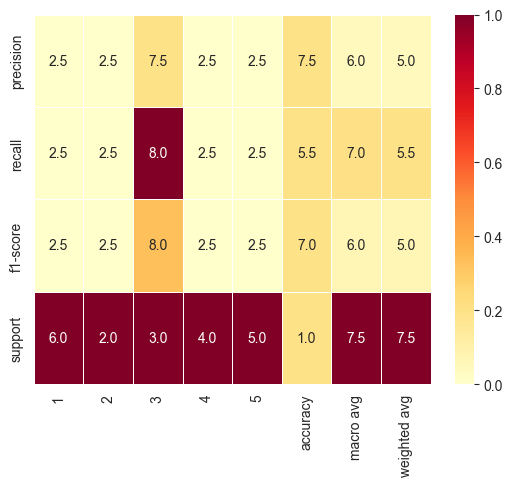

In [707]:
sns.heatmap(conv_cr, annot=conv_cr.rank(axis="columns"), fmt=".1f", linewidth=.5, vmin = 0, vmax = 1, cmap="YlOrRd") #Set up heatmap with class report metrics.

##### With F1, recall and precision generally yellow colors, this indicates that the logistic model underperformed. This is backed by the accuracy score of 0.19152276295133439; which indicates that the model did not correctly predict.

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

##### Reflecting on my analysis of the problem, ethical and privacy concerns include informed consent (hopefully recipients were informed of what they were getting into and how their info will be shared), misuse of data and accuracy.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [708]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

##### Does salary increase as the number of hits increase?

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [709]:
Hitters.shape

(322, 20)

In [710]:
Hitters.info() #Info of the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

In [711]:
Hitters.describe() #Summary stats of numerical columns.

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [712]:
Hitters.isnull().sum() #Displays missing and null values.

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [713]:
Hitters = Hitters.dropna() #Drop null values.
Hitters.isnull().sum() #Null values have been removed.

AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

##### The dimensions of the dataset is 263, 20. That is 263 rows and 20 columns. All columns except three are numerical. There were 59 null values in the salary column, which were removed.

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

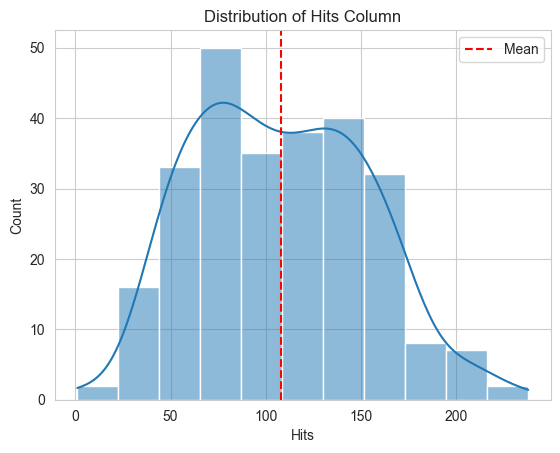

In [714]:
sns.histplot(data = Hitters, x = 'Hits', kde = True) #Plot Hits values.
plt.axvline(Hitters['Hits'].mean(), color = 'red', linestyle = '--', label = 'Mean')
plt.title("Distribution of Hits Column")
plt.legend()

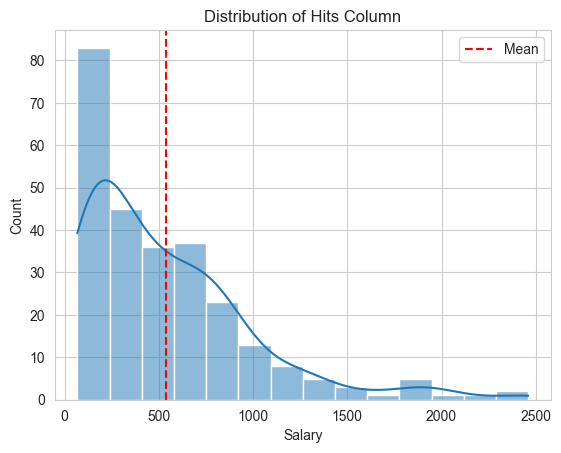

In [715]:
sns.histplot(data = Hitters, x = 'Salary', kde = True) #Plot Salary values.
plt.axvline(Hitters['Salary'].mean(), color = 'red', linestyle = '--', label = 'Mean')
plt.title("Distribution of Hits Column")
plt.legend()

In [716]:
Hitters[['Hits', 'Salary']].corr().loc['Hits', 'Salary'] #Compute correlation coefficient between the Hits and Salary columns.

np.float64(0.4386747378694112)

Text(0.5, 1.0, 'Relationship Between Hits and Salary\n')

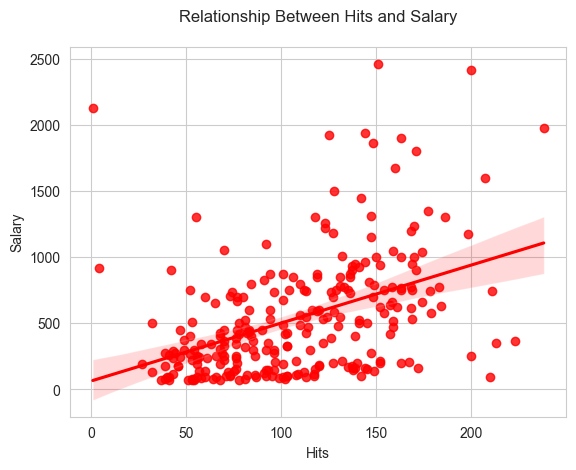

In [717]:
sns.set_style("whitegrid") #Set to whitegrid.
sns.regplot(data = Hitters, x = 'Hits', y = 'Salary', color = "red") #Plot relationship.
plt.xlabel('Hits') #Set x label title.
plt.ylabel('Salary') #Set y label title.
plt.title("Relationship Between Hits and Salary\n") #Set title.

Text(0.5, 1.0, 'Relationship Between Hits and Salary\n')

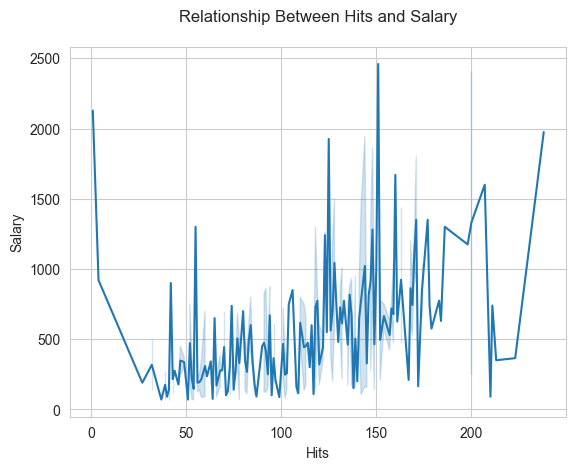

In [718]:
sns.set_style("whitegrid") #Set to whitegrid.
sns.lineplot(data = Hitters, x = 'Hits', y = 'Salary') #Plot relationship.
plt.xlabel('Hits') #Set x label title.
plt.ylabel('Salary') #Set y label title.
plt.title("Relationship Between Hits and Salary\n") #Set title.

##### Based on the correlation coefficient of 0.4386747378694112, there is a slightly moderate and positive relationship between the Hits and Salary columns. This is indicated in the two visualizations above. .4386 is on the weaker end, so more variables will be needed such as hmrun to strengthen the relationships and draw a firm conclusion. Of course, correlation does not necessarily imply causation.

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

##### I was able to answer all of the questions in problem 2 as they are well-defined. Yes, the data is good enough to answer all of the questions.

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [719]:
df = pd.read_csv('insurance.csv', low_memory = False) #Read and load data.
df.head() #Display first 5 rows.

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [720]:
df.info() #Displays dataset info.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [721]:
df.describe() #Summary stats of numerical variables.

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [722]:
df.isnull().sum() #No missing or null values.

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

Text(0.5, 1.0, 'Relationship Between Age and Charges\n')

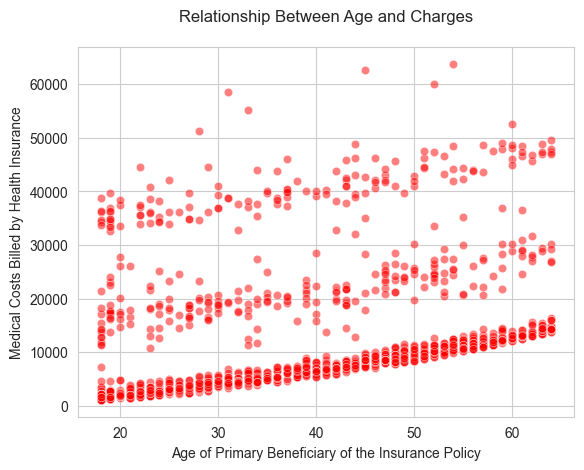

In [723]:
sns.set_style("whitegrid") #Set to whitegrid.
sns.scatterplot(data = df, x = 'age', y = 'charges', color = "red", alpha = 0.5) #Plot relationship.
plt.xlabel('Age of Primary Beneficiary of the Insurance Policy') #Set x label title.
plt.ylabel('Medical Costs Billed by Health Insurance') #Set y label title.
plt.title("Relationship Between Age and Charges\n") #Set title.

##### The relationship between the age and charges variables is positive, so as age increases, so does charges. There appears to be three sets of clustering. A few outliers are at the top.

Text(0.5, 1.0, 'Relationship Between Sex and Charges\n')

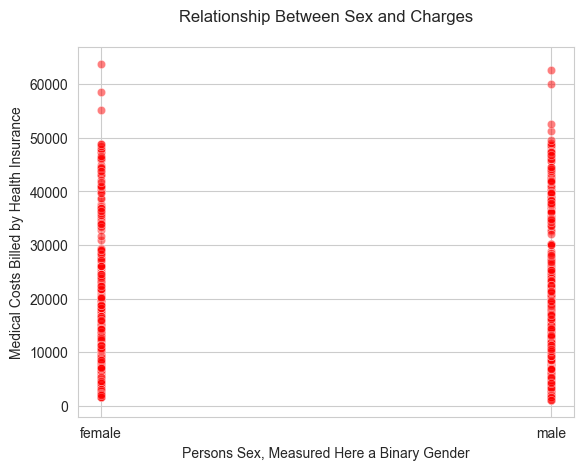

In [724]:
sns.set_style("whitegrid") #Set to whitegrid.
sns.scatterplot(data = df, x = 'sex', y = 'charges', color = "red", alpha = 0.5) #Plot relationship.
plt.xlabel('Persons Sex, Measured Here a Binary Gender') #Set x label title.
plt.ylabel('Medical Costs Billed by Health Insurance') #Set y label title.
plt.title("Relationship Between Sex and Charges\n") #Set title.

##### Since sex is binary, there are only two sets of data points (female and male charges). The visualization shows the distribution of charges based on female and male sex. Data points on a vertical line indicates no correlation between sex and charges. It appears that most data points for either sex concentrates below 50000 with outliers above 50000.

Text(0.5, 1.0, 'Relationship Between BMI and Charges\n')

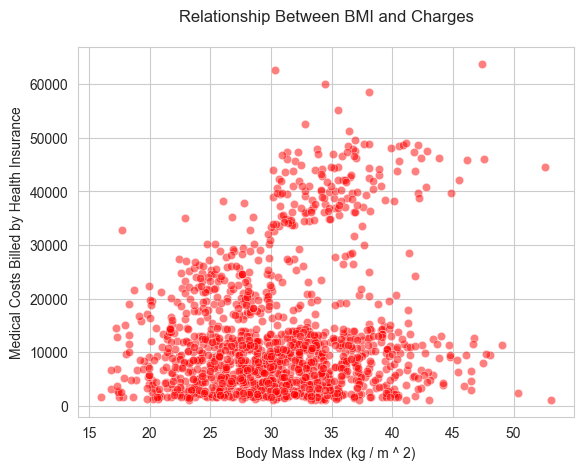

In [725]:
sns.set_style("whitegrid") #Set to whitegrid.
sns.scatterplot(data = df, x = 'bmi', y = 'charges', color = "red", alpha = 0.5) #Plot relationship.
plt.xlabel('Body Mass Index (kg / m ^ 2)') #Set x label title.
plt.ylabel('Medical Costs Billed by Health Insurance') #Set y label title.
plt.title("Relationship Between BMI and Charges\n") #Set title.

##### The relationship between BMI and charges appear to be somewhat positive. As BMI increases, so does charges. There is a concentration of data points from a BMI of 20 to 40 under 10000 charges. A few outliers deviate from the clustering.

Text(0.5, 1.0, 'Relationship Between Number of Children Covered by Health Insurance and Charges\n')

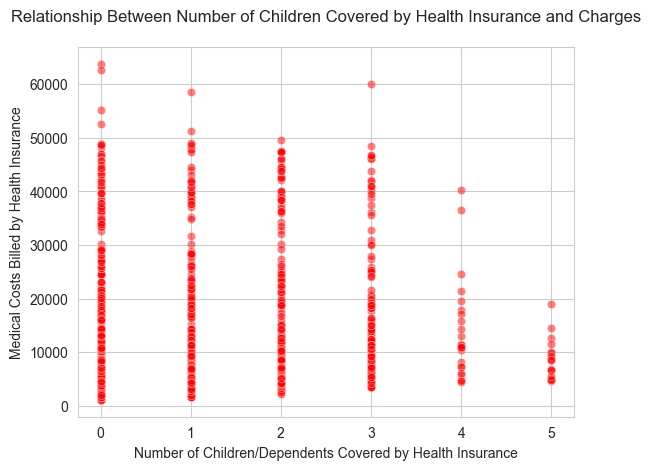

In [726]:
sns.set_style("whitegrid") #Set to whitegrid.
sns.scatterplot(data = df, x = 'children', y = 'charges', color = "red", alpha = 0.5) #Plot relationship.
plt.xlabel('Number of Children/Dependents Covered by Health Insurance') #Set x label title.
plt.ylabel('Medical Costs Billed by Health Insurance') #Set y label title.
plt.title("Relationship Between Number of Children Covered by Health Insurance and Charges\n") #Set title.

##### The data points vertically align on each number of children. This indicates that there is no real relationship between the number of children and charges. Outliers appear above each clustering. A good amount of the data points are concentrated below 30000 charges.

Text(0.5, 1.0, 'Relationship Between Smoking Status and Charges\n')

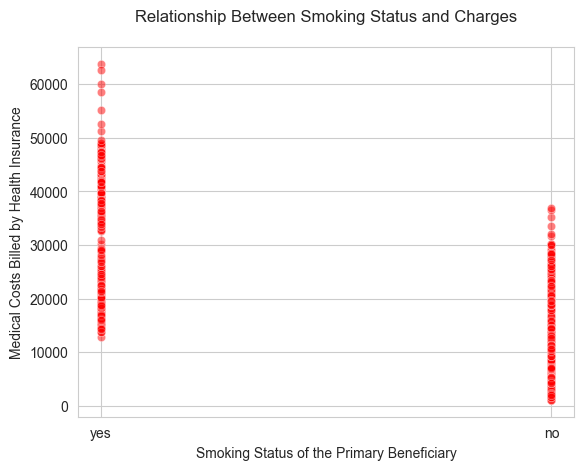

In [727]:
sns.set_style("whitegrid") #Set to whitegrid.
sns.scatterplot(data = df, x = 'smoker', y = 'charges', color = "red", alpha = 0.5) #Plot relationship.
plt.xlabel('Smoking Status of the Primary Beneficiary') #Set x label title.
plt.ylabel('Medical Costs Billed by Health Insurance') #Set y label title.
plt.title("Relationship Between Smoking Status and Charges\n") #Set title.

##### Since smoking status is binary, there are only two sets of data points (yes and no charges). The visualization shows the distribution of charges based on yes and no smoking responses. Data points on a vertical line indicate neither a positive or negative relationship between smoking status and charges. Most data points concentrate below 30000 charges for no and below 50000 for those who said yes (i.e., smokers).

Text(0.5, 1.0, 'Relationship Between Region and Charges\n')

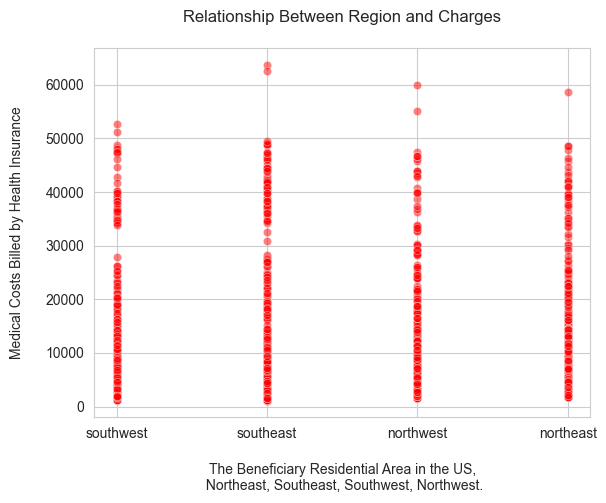

In [728]:
sns.set_style("whitegrid") #Set to whitegrid.
sns.scatterplot(data = df, x = 'region', y = 'charges', color = "red", alpha = 0.5) #Plot relationship.
plt.xlabel('\nThe Beneficiary Residential Area in the US,\n Northeast, Southeast, Southwest, Northwest.') #Set x label title.
plt.ylabel('Medical Costs Billed by Health Insurance\n') #Set y label title.
plt.title("Relationship Between Region and Charges\n") #Set title.

##### Since the region variable is categorical, there are only four sets of data points (S, SE, NW, NE). The visualization shows the distribution of charges based on U.S. region. Data points on a vertical line indicate neither a positive or negative relationship between region and charges. Most data points concentrate below 50000 charges with a few outliers above.

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [729]:
df['constant'] = 1
df['sex'] = df['sex'].replace({'male': 1, 'female': 0}) #Replace categorical with numerical values before modeling.
df['smoker'] = df['smoker'].replace({'yes': 1, 'no': 0}) #Replace categorical with numerical values before modeling.
df['region'] = df['region'].replace({'southwest': 1, 'southeast': 2, 'northwest': 3, 'northeast': 4}) #Replace categorical with numerical values before modeling.

/var/folders/1s/bsdc29gj1x16g8m2s5syblpm0000gn/T/ipykernel_3857/2097053426.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'male': 1, 'female': 0}) #Replace categorical with numerical values before modeling.
/var/folders/1s/bsdc29gj1x16g8m2s5syblpm0000gn/T/ipykernel_3857/2097053426.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'] = df['smoker'].replace({'yes': 1, 'no': 0}) #Replace categorical with numerical values before modeling.
/var/folders/1s/bsdc29gj1x16g8m2s5syblpm0000gn/T/

In [730]:
df.head() #Display changes made before regression analysis.

,age,sex,bmi,children,smoker,region,charges,constant
0,19,0,27.900,0,1,1,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,1
3,33,1,22.705,0,0,3,21984.47061,1
4,32,1,28.880,0,0,3,3866.85520,1


In [731]:
df.dtypes #Data types

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
constant      int64
dtype: object

In [732]:
mlr = sm.OLS(df['charges'], df.drop('charges', axis = 1)) #Set up multiple regression model.
model = mlr.fit() #Fit data.

In [733]:
model.summary() #Display summary of regression model.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     668.1
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:31:51   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1331   BIC:                         2.715e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
age          257.2881     11.886     21.647      0.000     233.971     280.605
sex         -131.1106    332.811     -0.394      0.694    -784.001     521.780
bmi          332.5701     27.722     11.997      0.000     278.186     386.954
children     479.3694    137.644      3.483      0.001     209.346     749.393
smoker      2.382e+04    411.843     57.839      0.000     2.3e+04    2.46e+04
region       353.6400    151.927      2.328      0.020      55.598     651.682
constant   -1.323e+04   1076.023    -12.295      0.000   -1.53e+04   -1.11e+04
==============================================================================
Omnibus:                      299.003   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              713.975
Skew:                           1.207   Prob(JB):                    9.17e-156
Kurtosis:                       5.642   Cond. No.                         335.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [734]:
mlr_bmi = sm.OLS(df['charges'], df['bmi']) #Set up regression model.
model2 = mlr_bmi.fit() #Fit data.
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                charges   R-squared (uncentered):                   0.564
Model:                            OLS   Adj. R-squared (uncentered):              0.563
Method:                 Least Squares   F-statistic:                              1726.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):                   6.10e-243
Time:                        09:31:51   Log-Likelihood:                         -14451.
No. Observations:                1338   AIC:                                  2.890e+04
Df Residuals:                    1337   BIC:                                  2.891e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
bmi          431.2982     10.381     41.546      0.000     410.933     451.663
==============================================================================
Omnibus:                      251.034   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              406.507
Skew:                           1.266   Prob(JB):                     5.35e-89
Kurtosis:                       3.939   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### The predictor BMI alone explains 56.4% variance in charges. Additionally, for every increase of charges, we can expect the charges to increase by 31.2982. 

##### As a whole, the predictor variables explain 87.4% in charges. Additionally, for every increase of charges, we can expect the charges to increase by their respective coefficients (e.g., bmi at 63.6868).

In [735]:
X = sm.add_constant(df['bmi'])
y = df['charges']
mlr_bmi_withconst = sm.OLS(y, X) #Set up regression model.
model2 = mlr_bmi_withconst.fit() #Fit data.
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           2.46e-13
Time:                        09:31:51   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.474   -2072.974    4458.849
bmi          393.8730     53.251      7.397      0.000     289.409     498.337
==============================================================================
Omnibus:                      261.030   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              431.091
Skew:                           1.297   Prob(JB):                     2.45e-94
Kurtosis:                       4.004   Cond. No.                         160.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [736]:
# Check for differences in the datasets
print("Dataset shape:", df.shape)
print("Missing values:\n", df[['bmi', 'charges']].isnull().sum())
print("\nCharges stats:\n", df['charges'].describe())
print("\nCorrelation:", df['bmi'].corr(df['charges']))
print("\nFirst few rows of charges:\n", df['charges'].head())

Dataset shape: (1338, 8)
Missing values:
 bmi        0
charges    0
dtype: int64

Charges stats:
 count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

Correlation: 0.19834096883362884

First few rows of charges:
 0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

Text(0.5, 0, '\nPredicted Values\n')

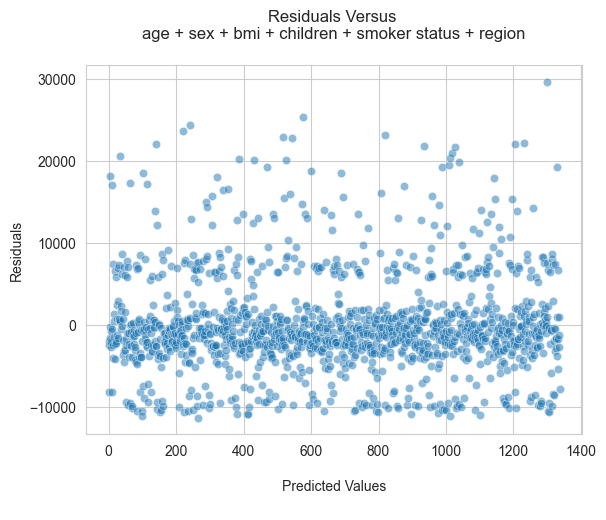

In [737]:
sns.scatterplot(model.resid, alpha = .5) #Plot residuals.
plt.title("Residuals Versus \nage + sex + bmi + children + smoker status + region\n")
plt.ylabel("Residuals")
plt.xlabel("\nPredicted Values\n")

##### There is a clustering around -2500 and 0. Additionally, the shape and distribution appear asymmetrical; thus, indicates a good fit. While there are outliers, the plot does not display any pattern of any type. Therefore, it is a good residual plot.

##### Data points above the 0 y-axis indicate that the predicted values relative to charges were lower than expected, and vice versa. The ones at 0 were predicted on the nose.

Text(0.5, 0, '\nPredicted Values\n')

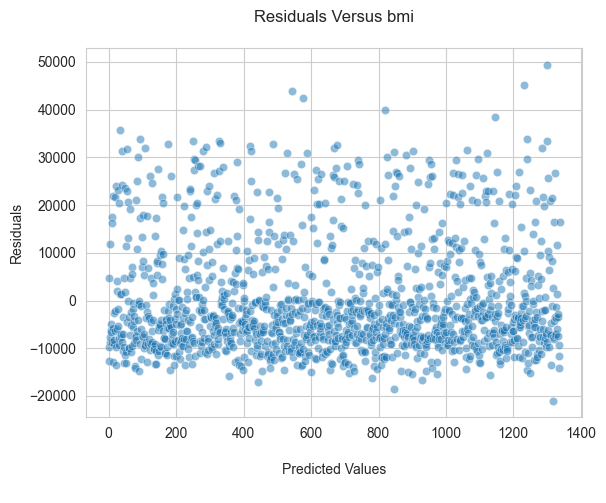

In [738]:
sns.scatterplot(model2.resid, alpha = .5) #Plot residuals.
plt.title("Residuals Versus bmi\n")
plt.ylabel("Residuals")
plt.xlabel("\nPredicted Values\n")

##### There is a clustering around -10000 and 0. Additionally, the shape and distribution appear asymmetrical; thus, indicates a good fit. While there are outliers, the plot does not display any pattern of any type. Therefore, it is a good residual plot.

##### Data points above the 0 y-axis indicate that the predicted values relative to charges were lower than expected, and vice versa. The ones at 0 were predicted on the nose.

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [739]:
mlr_age = sm.OLS(df['charges'], df['age']) #Set up regression model.
model3 = mlr_age.fit() #Fit data.
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                charges   R-squared (uncentered):                   0.583
Model:                            OLS   Adj. R-squared (uncentered):              0.583
Method:                 Least Squares   F-statistic:                              1868.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):                   3.95e-256
Time:                        09:31:51   Log-Likelihood:                         -14421.
No. Observations:                1338   AIC:                                  2.884e+04
Df Residuals:                    1337   BIC:                                  2.885e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
age          329.2873      7.618     43.224      0.000     314.343     344.232
==============================================================================
Omnibus:                      393.480   Durbin-Watson:                   2.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              840.455
Skew:                           1.714   Prob(JB):                    3.14e-183
Kurtosis:                       4.823   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [740]:
mlr_sex = sm.OLS(df['charges'], df['sex']) #Set up regression model.
model4 = mlr_sex.fit() #Fit data.
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                charges   R-squared (uncentered):                   0.305
Model:                            OLS   Adj. R-squared (uncentered):              0.305
Method:                 Least Squares   F-statistic:                              586.8
Date:                Sun, 07 Dec 2025   Prob (F-statistic):                   8.98e-108
Time:                        09:31:51   Log-Likelihood:                         -14762.
No. Observations:                1338   AIC:                                  2.953e+04
Df Residuals:                    1337   BIC:                                  2.953e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
sex         1.396e+04    576.153     24.224      0.000    1.28e+04    1.51e+04
==============================================================================
Omnibus:                      148.308   Durbin-Watson:                   1.709
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.441
Skew:                           0.881   Prob(JB):                     4.92e-44
Kurtosis:                       3.687   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [741]:
mlr_children = sm.OLS(df['charges'], df['children']) #Set up regression model.
model5 = mlr_children.fit() #Fit data.
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                charges   R-squared (uncentered):                   0.282
Model:                            OLS   Adj. R-squared (uncentered):              0.281
Method:                 Least Squares   F-statistic:                              524.3
Date:                Sun, 07 Dec 2025   Prob (F-statistic):                    3.64e-98
Time:                        09:31:51   Log-Likelihood:                         -14784.
No. Observations:                1338   AIC:                                  2.957e+04
Df Residuals:                    1337   BIC:                                  2.958e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
children    5855.1943    255.713     22.897      0.000    5353.551    6356.838
==============================================================================
Omnibus:                      178.390   Durbin-Watson:                   1.583
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              262.277
Skew:                           0.955   Prob(JB):                     1.11e-57
Kurtosis:                       4.029   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [742]:
mlr_smoker = sm.OLS(df['charges'], df['smoker']) #Set up regression model.
model6 = mlr_smoker.fit() #Fit data.
model6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                charges   R-squared (uncentered):                   0.652
Model:                            OLS   Adj. R-squared (uncentered):              0.652
Method:                 Least Squares   F-statistic:                              2505.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):                   1.00e-308
Time:                        09:31:51   Log-Likelihood:                         -14300.
No. Observations:                1338   AIC:                                  2.860e+04
Df Residuals:                    1337   BIC:                                  2.861e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
smoker      3.205e+04    640.409     50.046      0.000    3.08e+04    3.33e+04
==============================================================================
Omnibus:                       79.948   Durbin-Watson:                   1.190
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              226.414
Skew:                          -0.279   Prob(JB):                     6.84e-50
Kurtosis:                       4.936   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [743]:
mlr_region = sm.OLS(df['charges'], df['region']) #Set up regression model.
model7 = mlr_region.fit() #Fit data.
model7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                charges   R-squared (uncentered):                   0.458
Model:                            OLS   Adj. R-squared (uncentered):              0.458
Method:                 Least Squares   F-statistic:                              1130.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):                   4.67e-180
Time:                        09:31:51   Log-Likelihood:                         -14596.
No. Observations:                1338   AIC:                                  2.919e+04
Df Residuals:                    1337   BIC:                                  2.920e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
region      4471.3796    133.019     33.615      0.000    4210.430    4732.329
==============================================================================
Omnibus:                      266.538   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              455.583
Skew:                           1.273   Prob(JB):                     1.18e-99
Kurtosis:                       4.300   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### Using a stepwise model selection via a backward elimination approach, the model with the highest adjusted R^2 is model (includes all of the predictors) at 0.751. This model contains the "best" fit (Diez, 2019).

##### The individual models differ as they are linear regression models that include a single independent value versus the full model where all of the independent values are included in the analysis.

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

In [744]:
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

In [745]:
y_reg = df['charges'] #Regression tree x.
X_reg = df.drop(['charges'],  axis = 1) #Regression tree y.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.2, random_state = 11)
reg = tree.DecisionTreeRegressor(max_depth = 2) #Regression tree setup.
reg.fit(X_train_reg, y_train_reg) #Fit to model.

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [746]:
preds = reg.predict(X_train_reg) #Predictions with trained data.

In [747]:
np.sqrt(mean_squared_error(preds, y_train_reg)) #Evaluate accuracy of trained reg tree model. Off by 5140 (difference between predicted and actual values).

np.float64(5140.451151671116)

In [748]:
preds_test = reg.predict(X_test_reg) #Predictions with test data.

In [749]:
np.sqrt(mean_squared_error(preds_test, y_test_reg)) #Evaluate accuracy of trained reg tree model. Off by 4596 (difference between predicted and actual values).

np.float64(4596.8294387009555)

In [750]:
def cross_validated_trees(depth): #Set up cross validation tree.
    scores = cross_val_score(tree.DecisionTreeRegressor(max_depth = depth), X_train_reg, y_train_reg, cv = 5)
    print("Current Depth:", depth)
    print("\t Cross validation scores: ", scores)
    print("\t Mean score: ", np.mean(scores))

for x in [1, 3, 5, 10, 15, 25, 50]:
    cross_validated_trees(x)

Current Depth: 1
	 Cross validation scores:  [0.53602991 0.58314686 0.6653087  0.58838417 0.60303277]
	 Mean score:  0.5951804815267214
Current Depth: 3
	 Cross validation scores:  [0.79693261 0.8113743  0.88340904 0.83154853 0.84234748]
	 Mean score:  0.833122392835657
Current Depth: 5
	 Cross validation scores:  [0.80476268 0.79366888 0.89678986 0.84147421 0.83477461]
	 Mean score:  0.8342940453745286
Current Depth: 10
	 Cross validation scores:  [0.67687843 0.70840878 0.82855042 0.74224094 0.70299684]
	 Mean score:  0.731815081568344
Current Depth: 15
	 Cross validation scores:  [0.62428685 0.69849568 0.76331993 0.71826138 0.68871311]
	 Mean score:  0.6986153893463557
Current Depth: 25
	 Cross validation scores:  [0.62492537 0.71819455 0.75985169 0.71495679 0.70255787]
	 Mean score:  0.7040972541191008
Current Depth: 50
	 Cross validation scores:  [0.62227309 0.69117771 0.7742095  0.72846631 0.70270722]
	 Mean score:  0.7037667638900624


##### Comparing the results from the two trees, I would prefer cross validation as the best cross validation tree produced a mean score of .834, indicating that the model performed well with a high cv-accuracy compared to the regression tree which is off by 5000.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [751]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [752]:
data = pd.read_csv(location + dataframe) #Read file.
data.head()

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [753]:
data = data.rename(columns = {'1000025':'Sample_code_number', '5':'Clump_thickness', '1':'Uniformity_of_cell_size', '1.1': 'Uniformity_of_cell_shape', '1.2':'Marginal_adhesion', '2':'Single_epithelial_cell_size', '1.3':'Bare_nuclei', '3':'Bland_chromatin', '1.4':'Normal_nucleoli', '1.5':'Mitoses', '2.1':'Class'}) #Rename columns from https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original.
data.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [754]:
data.shape #Dimensions of dataframe.

(698, 11)

In [755]:
data.info() #Info of dataframe.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample_code_number           698 non-null    int64 
 1   Clump_thickness              698 non-null    int64 
 2   Uniformity_of_cell_size      698 non-null    int64 
 3   Uniformity_of_cell_shape     698 non-null    int64 
 4   Marginal_adhesion            698 non-null    int64 
 5   Single_epithelial_cell_size  698 non-null    int64 
 6   Bare_nuclei                  698 non-null    object
 7   Bland_chromatin              698 non-null    int64 
 8   Normal_nucleoli              698 non-null    int64 
 9   Mitoses                      698 non-null    int64 
 10  Class                        698 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [756]:
data.describe() #Summary stats of numerical columns.

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,6.980000e+02,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000
mean,1.071807e+06,4.416905,3.137536,3.210602,2.809456,3.217765,3.438395,2.869628,1.590258,2.690544
std,6.175323e+05,2.817673,3.052575,2.972867,2.856606,2.215408,2.440056,3.055004,1.716162,0.951596
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.702582e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238354e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [757]:
data.isnull().sum() #Display number of null values.

Sample_code_number             0
Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

In [758]:
data = data.astype({'Class': 'category'}) #Convert class variable dtype to category.
data.dtypes

Sample_code_number                int64
Clump_thickness                   int64
Uniformity_of_cell_size           int64
Uniformity_of_cell_shape          int64
Marginal_adhesion                 int64
Single_epithelial_cell_size       int64
Bare_nuclei                      object
Bland_chromatin                   int64
Normal_nucleoli                   int64
Mitoses                           int64
Class                          category
dtype: object

In [759]:
data['Bare_nuclei'].unique() #There is an ? in the column.

array(['10', '2', '4', '1', '3', '9', '7', '?', '5', '8', '6'],
      dtype=object)

In [760]:
data['Bare_nuclei'] = data['Bare_nuclei'].replace('', 0) #Replace with 0.
data = data.astype({'Bare_nuclei': 'int'}) #Convert obj variable dtype to int.

ValueError: invalid literal for int() with base 10: '?': Error while type casting for column 'Bare_nuclei'

In [204]:
data.dtypes

Sample_code_number                int64
Clump_thickness                   int64
Uniformity_of_cell_size           int64
Uniformity_of_cell_shape          int64
Marginal_adhesion                 int64
Single_epithelial_cell_size       int64
Bare_nuclei                       int64
Bland_chromatin                   int64
Normal_nucleoli                   int64
Mitoses                           int64
Class                          category
dtype: object

##### There are no missing or null values. Each variable has been properly named via the Variables Table on https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original. Dimensions is 698, 11. Only Class variable is category dtype.

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [205]:
X = data.drop('Class', axis = 1)
y = data['Class']

In [208]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42) #Split data into training and test with random 70% of observations in the training set.
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train) #Fit the model

C:\Users\19254\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [209]:
log_reg.coef_ #Coefficients

array([[-5.39988715e-06,  2.99492485e-01,  4.97662346e-01,
         4.69096537e-01,  3.76463532e-02, -4.54878375e-01,
         3.90806060e-01,  1.03933023e-01,  1.36465006e-01,
         4.41585256e-02]])

In [210]:
log_reg.intercept_ #Intercept

array([-0.41934082])

In [211]:
pred = log_reg.predict(X_test)
conf = confusion_matrix(y_test, pred)
conf

array([[126,   9],
       [  8,  67]])

In [214]:
class_report = classification_report(y_test, pred, output_dict = True) #Classification report.

In [215]:
class_report['accuracy']

0.919047619047619

##### Based on the confusion matrix, 125 is number of true negatives, 9 is false positives, 8 is false negatives and 67 is true positives. The accuracy score from the confusion matrix and class report is 0.919047619047619; which is approximately 91.9% as a percentage. In other words, the model did predict pretty accurately.

##### From the errors, false negatives and false positives are problematic. The model predicted 9 false positives/malignant when they were benign, and predicted 8 false positives/benign when they were malignant. Both can lead to unnecessary stress and anxiety.

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

##### Three real-life applications in which classification might be useful is cancer diagnosis as with problem 4, loan approval and customer recommendation.

##### Cancer diagnosis: benign/malignant vs size of tumor, color, hairness, bleeding, pain
##### Loan approval: yes/no vs length of credit history, balance to credit ratio, delinquencies, late payments
##### customer recommendation: 1/2/3/4/5 vs browsing history, purchase history, likes, returns

##### Each application will be predicting rather than inferring.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

##### Weather forecast: rain/no rain vs month_history, last_week_weather, humidity, air pressure
##### Rental prices: increase yes/increase no vs past twelve rental history prices, current payments, late payments, housing prices
##### Blood pressure: high/low vs past visit readings, current dosage, existing ailments, supplements, exercise per day

##### The first two will predict, while the x values will infer high/low blood pressure using p-values.

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

##### A very flexible approach avoids/prevents bias from seeping through. Also, this is assuming the sample size is larger. Additionally, predictions may be more accurate.

##### A more flexible approach be preferred when making predictions, whereas a less flexible approach be preferred when you are inferring with a smaller dataset.

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

##### iv is correct as B_0 is 50, while B_1 is 20.

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

##### y = 

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

##### False. While coefficient indicate strength of relationship, there are other variables that come into play.

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

In [ ]:
# NOTE THIS CODE WILL NOT RUN 
# UNTIL YOU WRITE YOUR WEB SCRAPING FUNCTIONS

# Get songs
artist = 'Adele'
all_songs = get_songs(artist) 

# Get lyrics -- internally, you may want to another function in your library, such as get_lyrics()
lyrics = get_all_lyrics(songs)

# Save data -- this function should identify the name of the artist and use it in the .csv file it saves
save_lyrics(lyrics)

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  